# MVPC Analysis on MIMIC Dataset

## Objective

This notebook evaluates the MVPC algorithm on real clinical data from the MIMIC-IV dataset.  
We examine the structure of lab measurements and demographic variables under different simulated missingness scenarios.

## Data

- The aggregated mimic dataset is used, and the variables included were lab values (`Sodium`, `Potassium`, etc.) and demographics (`anchor_age`, `length_of_stay_hours`).
- Missingness is synthetically injected according to MAR and MNAR mechanisms using `create_mar_ind()` and `create_mnar_ind()`.
- The missingness structure is informed by plausible parent-child relationships between variables.


## Experimental Methodology
To test the robustness of the algorithm, we simulate structured missingness using adjacency matrices that define parent-child dependencies for missing values:

- Missing at Random (MAR): Missingness is conditioned on observed clinical values.
- Missing Not at Random (MNAR): Missingness is self-masking or governed by latent severity drivers.

The pipeline executes the following for each configuration ($n \in \{120, 150, 200, 300\}$ over 100 repetitions)

For each sample size and repetition:
   - Draw a bootstrap sample from the MIMIC data
   - Inject MAR and MNAR missingness based on the defined structures.
   - Run MVPC with different CI test corrections (TD, PermC, DRW)


## Evaluation Metrics
The recovered causal skeletons are compared against the Reference Skeleton using:

- Structural Hamming Distance (SHD): To quantify total edge disagreements.

- Precision, Recall, and F1-Score: To measure the accuracy and coverage of the recovered causal relationships.

- Edge Frequency Matrices: To visualize the stability of specific causal links across repetitions.

In [1]:
import sys
import os


project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: c:\Users\sofia\OneDrive\Υπολογιστής\Thesis_New


In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from mvpc.mvpc_pipeline import MVPC
from mvpc.ci_tests.gauss_permc import gauss_ci_td, gauss_ci_permc
from mvpc.ci_tests.gauss_drw import gauss_ci_drw

from data.synthetic_data_generation.missingness_synthetic import (
    create_mar_ind, create_mnar_ind,
    generate_missing_values
)

# Define variables for MVPC analysis
mvpc_vars = [
    "Sodium", "Potassium", "Chloride", "Creatinine", "Urea Nitrogen",
    "Hematocrit", "Hemoglobin", "Platelet Count", "Glucose",
    "anchor_age", "length_of_stay_hours",
]


df = pd.read_csv("../data/processed_mimic/processed_mimic_24h_labs_demographics.csv")
mimic_data = df[mvpc_vars].dropna().reset_index(drop=True)



# Log-transforming skewed variables to satisfy Gaussian assumptions
cols_to_transform = [
    "Creatinine", "Urea Nitrogen", "Glucose", 
    "length_of_stay_hours", "Sodium", "Potassium", "Chloride"
]

for col in cols_to_transform:
    mimic_data[col] = np.log1p(mimic_data[col])

print("Data transformed to improve Gaussian CI test performance.")

num_var = len(mvpc_vars)
idx = {v: i for i, v in enumerate(mvpc_vars)}

print("MIMIC data shape:", mimic_data.shape)
mimic_data.head()

Data transformed to improve Gaussian CI test performance.
MIMIC data shape: (218, 11)


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
0,4.927254,1.704748,4.663439,0.262364,3.258097,37.6,12.7,71.0,4.605170,52,2.989043
1,4.844187,1.824549,4.532599,0.262364,3.401197,35.5,12.4,137.0,4.276666,52,3.233436
2,4.844187,2.028148,4.559126,0.470004,3.637586,34.6,12.1,133.0,4.564348,52,3.763523
3,4.882802,1.766442,4.634729,0.371564,3.449988,34.8,11.9,94.0,4.718499,52,3.995138
4,4.962845,1.629241,4.653960,0.405465,2.484907,37.4,12.5,301.0,4.477337,55,4.962495


In [3]:
print(mimic_data.shape)

(218, 11)


In [4]:
def build_missingness_structure(adj):
    
    ms = []
    prt = {}

    k = adj.shape[0]

    for j in range(k):

        parents = list(np.where(adj[:, j] == 1)[0])

        if len(parents) > 0:
            ms.append(j)
            prt[j] = parents

    return ms, prt

In [ ]:
adj_missing_mar = np.zeros((num_var, num_var))

# Creatinine missingness (depends on electrolytes)
adj_missing_mar[idx["Sodium"], idx["Creatinine"]] = 1
adj_missing_mar[idx["Potassium"], idx["Creatinine"]] = 1
adj_missing_mar[idx["Chloride"], idx["Creatinine"]] = 1

# Glucose missingness (demographics + labs)
adj_missing_mar[idx["anchor_age"], idx["Glucose"]] = 1
adj_missing_mar[idx["Sodium"], idx["Glucose"]] = 1
adj_missing_mar[idx["Chloride"], idx["Glucose"]] = 1

# Urea Nitrogen missingness
adj_missing_mar[idx["Creatinine"], idx["Urea Nitrogen"]] = 1
adj_missing_mar[idx["Hematocrit"], idx["Urea Nitrogen"]] = 1

# Hematocrit missingness
adj_missing_mar[idx["Hemoglobin"], idx["Hematocrit"]] = 1
adj_missing_mar[idx["Platelet Count"], idx["Hematocrit"]] = 1

# Platelet Count missingness
adj_missing_mar[idx["Hemoglobin"], idx["Platelet Count"]] = 1
adj_missing_mar[idx["Glucose"], idx["Platelet Count"]] = 1

# Length of stay missingness
adj_missing_mar[idx["anchor_age"], idx["length_of_stay_hours"]] = 1
adj_missing_mar[idx["Urea Nitrogen"], idx["length_of_stay_hours"]] = 1



In [6]:
print("Variables:", mvpc_vars)
print("Number of variables:", num_var)
print("Missingness adjacency shape:", adj_missing_mar.shape)

Variables: ['Sodium', 'Potassium', 'Chloride', 'Creatinine', 'Urea Nitrogen', 'Hematocrit', 'Hemoglobin', 'Platelet Count', 'Glucose', 'anchor_age', 'length_of_stay_hours']
Number of variables: 11
Missingness adjacency shape: (11, 11)


In [7]:
from data.synthetic_data_generation.dag_and_data import (
    detect_colliders, detect_collider_parents
)

colliders = detect_colliders(adj_missing_mar)
collider_parents = detect_collider_parents(adj_missing_mar, colliders)

In [ ]:
adj_missing_mnar = np.zeros((num_var, num_var))

# Shared severity driver
adj_missing_mnar[idx["Creatinine"], idx["Glucose"]] = 1
adj_missing_mnar[idx["Creatinine"], idx["Hematocrit"]] = 1
adj_missing_mnar[idx["Creatinine"], idx["Platelet Count"]] = 1
adj_missing_mnar[idx["Creatinine"], idx["Urea Nitrogen"]] = 1

# Glucose missingness
adj_missing_mnar[idx["Glucose"], idx["Hematocrit"]] = 1
adj_missing_mnar[idx["Platelet Count"], idx["Glucose"]] = 1
adj_missing_mnar[idx["Urea Nitrogen"], idx["Glucose"]] = 1

# Hematocrit missingness
adj_missing_mnar[idx["Glucose"], idx["Hematocrit"]] = 1
adj_missing_mnar[idx["Platelet Count"], idx["Hematocrit"]] = 1
adj_missing_mnar[idx["Creatinine"], idx["Hematocrit"]] = 1

# Platelet Count missingness
adj_missing_mnar[idx["Creatinine"], idx["Platelet Count"]] = 1
adj_missing_mnar[idx["Glucose"], idx["Platelet Count"]] = 1
adj_missing_mnar[idx["Urea Nitrogen"], idx["Platelet Count"]] = 1

# Length of stay missingness
adj_missing_mnar[idx["Creatinine"], idx["length_of_stay_hours"]] = 1
adj_missing_mnar[idx["Urea Nitrogen"], idx["length_of_stay_hours"]] = 1
adj_missing_mnar[idx["Glucose"], idx["length_of_stay_hours"]] = 1
adj_missing_mnar[idx["Hematocrit"], idx["length_of_stay_hours"]] = 1



In [9]:
ms_mar, prt_ms_mar = build_missingness_structure(adj_missing_mar)
ms_mnar, prt_ms_mnar = build_missingness_structure(adj_missing_mnar)

print("Variables with missingness:", ms_mar)
print("Parent structure:", prt_ms_mar)

print("_____________________________________________________________________________")

print("Variables with missingness:", ms_mnar)
print("Parent structure:", prt_ms_mnar)

Variables with missingness: [3, 4, 5, 7, 8, 10]
Parent structure: {3: [np.int64(0), np.int64(1), np.int64(2)], 4: [np.int64(3), np.int64(5)], 5: [np.int64(6), np.int64(7)], 7: [np.int64(6), np.int64(8)], 8: [np.int64(0), np.int64(2), np.int64(9)], 10: [np.int64(4), np.int64(9)]}
_____________________________________________________________________________
Variables with missingness: [4, 5, 7, 8, 10]
Parent structure: {4: [np.int64(3)], 5: [np.int64(3), np.int64(7), np.int64(8)], 7: [np.int64(3), np.int64(4), np.int64(8)], 8: [np.int64(3), np.int64(4), np.int64(7)], 10: [np.int64(3), np.int64(4), np.int64(5), np.int64(8)]}


In [10]:
def edge_frequency_matrix(skeleton_list):
    k = skeleton_list[0].shape[0]
    F = np.zeros((k, k))
    R = len(skeleton_list)
    for S in skeleton_list:
        F += S
    F /= R
    return F


In [ ]:
X_full = mimic_data.to_numpy()

mvpc_td = MVPC(
    indep_test=gauss_ci_td,
    corr_test=gauss_ci_td,
    alpha=0.05
)

n_reps_ref = 300
skeletons_ref = []


for rep in range(n_reps_ref):

    X_boot = mimic_data.sample(
        len(mimic_data),
        replace=True,
        random_state=rep
    ).to_numpy()

    out = mvpc_td.run(X_boot)

    G = out["G_corrected"]
    S = ((G + G.T) > 0).astype(int)

    skeletons_ref.append(S)

F_ref = edge_frequency_matrix(skeletons_ref)

threshold = 0.6
skeleton_ref = (F_ref >= threshold).astype(int)


print(f"Reference edges (Stricter): {skeleton_ref.sum() / 2}")

In [12]:
print("Reference edges:", skeleton_ref.sum() / 2)

Reference edges: 6.0


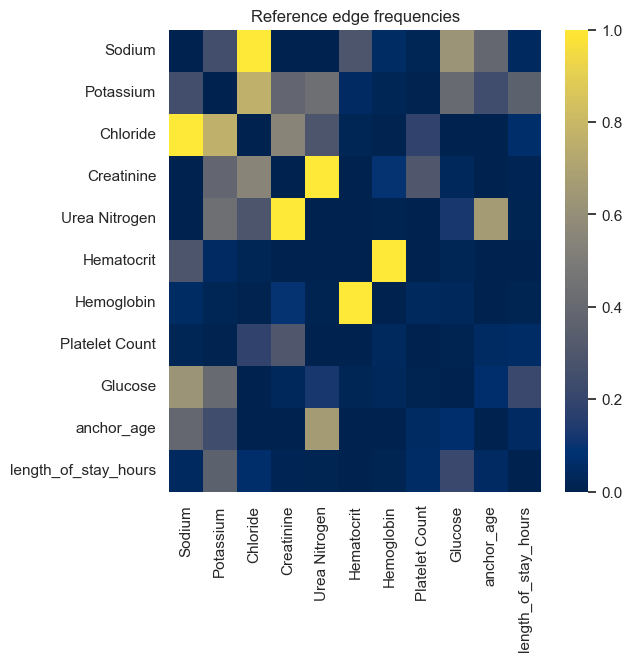

In [13]:
plt.figure(figsize=(6,6))
sns.heatmap(
    F_ref,
    xticklabels=mvpc_vars,
    yticklabels=mvpc_vars,
    cmap="cividis",
    vmin=0,
    vmax=1
)
plt.title("Reference edge frequencies")
plt.show()

In [14]:
def compare_skeletons(S_est, S_ref):
    triu = np.triu_indices_from(S_ref, k=1)
    est = S_est[triu]
    ref = S_ref[triu]

    TP = np.sum((est == 1) & (ref == 1))
    FP = np.sum((est == 1) & (ref == 0))
    FN = np.sum((est == 0) & (ref == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan
    shd = FP + FN

    return dict(TP=TP, FP=FP, FN=FN,
                precision=precision, recall=recall,
                f1=f1, shd=shd)


In [ ]:
sample_sizes = [ 120, 150, 200, 300]
n_reps = 100  

num_extra_e = 5
num_m = 6

# MAR
p_missing_h_mar = 0.5
p_missing_l_mar = 0.2

# MNAR
p_missing_h_mnar = 0.8
p_missing_l_mnar = 0.3


modes = ["MAR", "MNAR"]
methods = ["td", "permc", "drw"]


In [16]:
all_runs = []  
all_skeletons = {}  


In [17]:
def add_skeleton(mode, method, n, skeleton):
    key = (mode, method, n)
    if key not in all_skeletons:
        all_skeletons[key] = []
    all_skeletons[key].append(skeleton)


In [ ]:
import gc

for n in sample_sizes:

    for rep in range(n_reps):

        
        X_complete = mimic_data.sample(n, replace=True, random_state=rep).to_numpy()
        
        
        mvpc_baseline = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_td, alpha=0.05)
        out_td = mvpc_baseline.run(X_complete)
        G_td = out_td["G_corrected"]
        S_td = ((G_td + G_td.T) > 0).astype(int)
        
        
        comp_baseline = compare_skeletons(S_td, skeleton_ref)

        all_runs.append({
            "mode": "complete",
            "method": "td",
            "n": n,
            "rep": rep,
            "num_edges": S_td.sum()/2,
            "density": (S_td.sum()/2) / (num_var*(num_var-1)/2),
            **comp_baseline
        })

        # Generate missing data
        X_mar = generate_missing_values(
            X_complete, ms_mar, prt_ms_mar,
            p_missing_h=p_missing_h_mar, p_missing_l=p_missing_l_mar, seed=rep
        )
        X_mnar = generate_missing_values(
            X_complete, ms_mnar, prt_ms_mnar,
            p_missing_h=p_missing_h_mnar, p_missing_l=p_missing_l_mnar, seed=rep
        )
        
        print("MAR missing fraction:", np.isnan(X_mar).mean())
        print("MNAR missing fraction:", np.isnan(X_mnar).mean())

        # MVPC for each method
        for mode, X_m in [("MAR", X_mar), ("MNAR", X_mnar)]:
            for method in methods:
                

                if method == "td":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_td, alpha=0.05)
                elif method == "permc":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_permc, alpha=0.05)
                elif method == "drw":
                    mvpc = MVPC(indep_test=gauss_ci_td, corr_test=gauss_ci_drw, alpha=0.05)
                

                out_mvpc = mvpc.run(X_m)
                G_mvpc = out_mvpc["G_corrected"]
                
                S_mvpc = ((G_mvpc + G_mvpc.T) > 0).astype(int)
                

                # Skeleton
                skeleton_mvpc = ((G_mvpc + G_mvpc.T) > 0).astype(int)
                num_edges = S_mvpc.sum() / 2
                max_edges = num_var * (num_var - 1) / 2
                density = num_edges / max_edges
                
                comp = compare_skeletons(S_mvpc, skeleton_ref)

                all_runs.append({
                    "mode": mode,
                    "method": method,
                    "n": n,
                    "rep": rep,
                    "num_edges": num_edges,
                    "density": density,
                    **comp
                })
                
                add_skeleton(mode, method, n, skeleton_mvpc)
                

        del out_mvpc, G_mvpc, skeleton_mvpc 
        gc.collect()



In [19]:
stable_results = []

for key, skeleton_list in all_skeletons.items():

    mode, method, n = key

    F = edge_frequency_matrix(skeleton_list)

    S_stable = (F >= 0.6).astype(int)

    comp = compare_skeletons(S_stable, skeleton_ref)

    num_edges = S_stable.sum() / 2
    density = num_edges / (num_var*(num_var-1)/2)

    stable_results.append({
        "mode": mode,
        "method": method,
        "n": n,
        "num_edges": num_edges,
        "density": density,
        **comp
    })

In [ ]:
df_stable = pd.DataFrame(stable_results)

In [21]:
df_runs = pd.DataFrame(all_runs)

summary_metrics = (
    df_runs.groupby(["mode", "method", "n"])
           .agg(mean_f1=("f1", "mean"),
                sd_f1=("f1", "std"),
                mean_shd=("shd", "mean"),
                sd_shd=("shd", "std"),
                mean_precision=("precision", "mean"),
                mean_recall=("recall", "mean"))
           .reset_index()
)

summary_metrics



,mode,method,n,mean_f1,sd_f1,mean_shd,sd_shd,mean_precision,mean_recall
0,MAR,drw,120,0.643747,0.117770,4.49,1.696669,0.637266,0.663333
1,MAR,drw,150,0.645923,0.117865,4.57,1.713022,0.620829,0.686667
2,MAR,drw,200,0.649736,0.111444,4.79,1.659348,0.586704,0.735000
3,MAR,drw,300,0.652940,0.120174,5.09,1.907428,0.561095,0.791667
4,MAR,permc,120,0.645176,0.115987,4.47,1.666394,0.638516,0.665000
5,MAR,permc,150,0.647663,0.119504,4.55,1.737146,0.622734,0.688333
6,MAR,permc,200,0.649346,0.114450,4.80,1.717409,0.586440,0.735000
7,MAR,permc,300,0.652463,0.122085,5.08,1.899920,0.561252,0.790000
8,MAR,td,120,0.643842,0.116502,4.50,1.684750,0.636294,0.665000
9,MAR,td,150,0.645113,0.118631,4.60,1.734964,0.618302,0.688333


In [22]:
summary_rep = (
    df_runs.groupby(["mode","method","n"])
    .agg(
        mean_f1=("f1","mean"),
        sd_f1=("f1","std"),
        mean_shd=("shd","mean"),
        sd_shd=("shd","std")
    )
    .reset_index()
)

In [23]:
df_stable = df_stable.rename(columns={
    "f1":"stable_f1",
    "shd":"stable_shd"
})

In [24]:
comparison = summary_rep.merge(
    df_stable[["mode","method","n","stable_f1","stable_shd"]],
    on=["mode","method","n"]
)

comparison

,mode,method,n,mean_f1,sd_f1,mean_shd,sd_shd,stable_f1,stable_shd
0,MAR,drw,120,0.643747,0.117770,4.49,1.696669,0.8,2
1,MAR,drw,150,0.645923,0.117865,4.57,1.713022,0.8,2
2,MAR,drw,200,0.649736,0.111444,4.79,1.659348,0.8,2
3,MAR,drw,300,0.652940,0.120174,5.09,1.907428,0.8,2
4,MAR,permc,120,0.645176,0.115987,4.47,1.666394,0.8,2
5,MAR,permc,150,0.647663,0.119504,4.55,1.737146,0.8,2
6,MAR,permc,200,0.649346,0.114450,4.80,1.717409,0.8,2
7,MAR,permc,300,0.652463,0.122085,5.08,1.899920,0.8,2
8,MAR,td,120,0.643842,0.116502,4.50,1.684750,0.8,2
9,MAR,td,150,0.645113,0.118631,4.60,1.734964,0.8,2


In [26]:
summary_density = (
    df_runs.groupby(["mode", "method", "n"])
           .agg(mean_edges=("num_edges", "mean"),
                mean_density=("density", "mean"),
                sd_density=("density", "std"))
           .reset_index()
)

summary_density


,mode,method,n,mean_edges,mean_density,sd_density
0,MAR,drw,120,6.45,0.117273,0.023455
1,MAR,drw,150,6.81,0.123818,0.023500
2,MAR,drw,200,7.61,0.138364,0.018972
3,MAR,drw,300,8.59,0.156182,0.025068
4,MAR,permc,120,6.45,0.117273,0.023455
5,MAR,permc,150,6.81,0.123818,0.023642
6,MAR,permc,200,7.62,0.138545,0.020147
7,MAR,permc,300,8.56,0.155636,0.024964
8,MAR,td,120,6.48,0.117818,0.023893
9,MAR,td,150,6.86,0.124727,0.023968


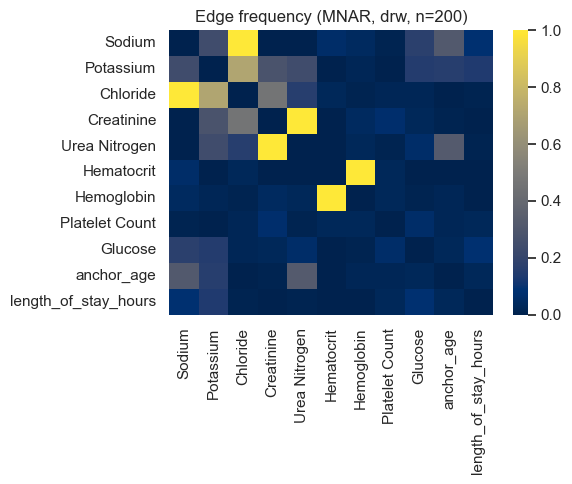

In [ ]:
def edge_frequency_matrix(skeleton_list):
    k = skeleton_list[0].shape[0]
    F = np.zeros((k, k))
    R = len(skeleton_list)
    for S in skeleton_list:
        F += S
    F /= R
    return F

mode = "MNAR"
method = "drw"
n = 200

F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

plt.figure(figsize=(6, 5))
sns.heatmap(F, xticklabels=mvpc_vars, yticklabels=mvpc_vars, cmap="cividis", vmin=0, vmax=1)
plt.title(f"Edge frequency ({mode}, {method}, n={n})")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


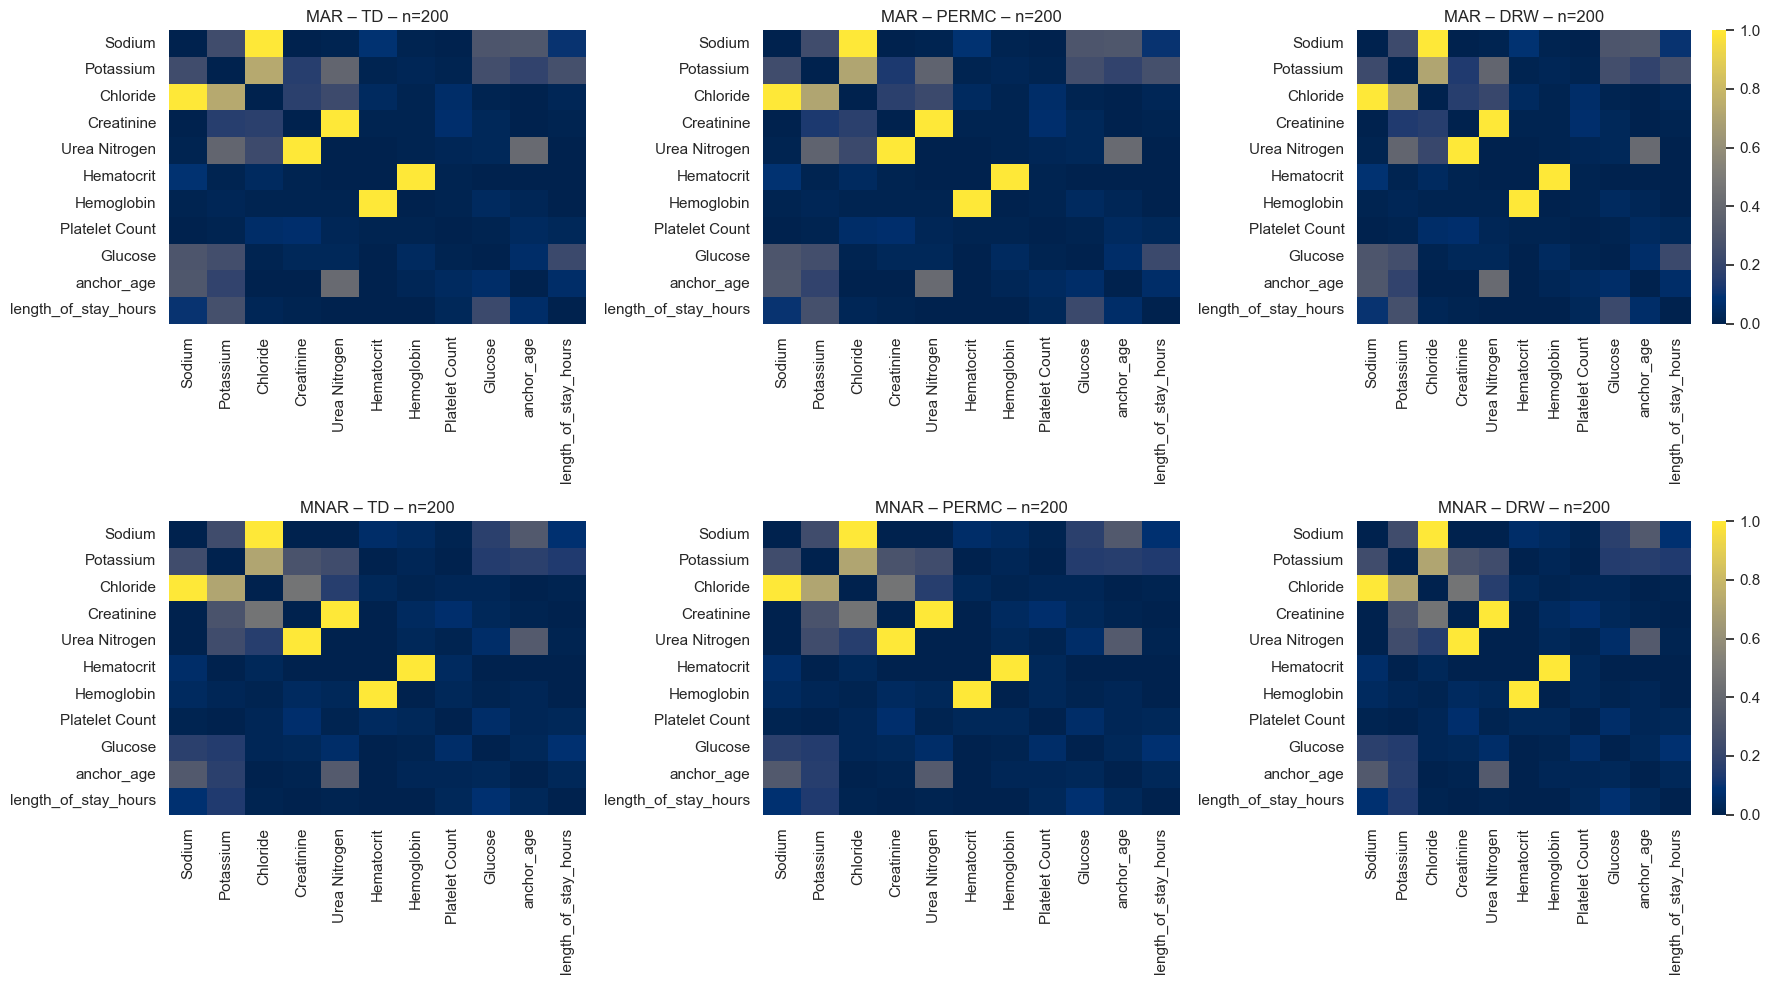

In [30]:
methods = ["td", "permc", "drw"]
modes = ["MAR", "MNAR"]
n = 200   
fig, axes = plt.subplots(len(modes), len(methods), figsize=(18, 10))

for i, mode in enumerate(modes):
    for j, method in enumerate(methods):

        # Compute edge frequency matrix
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

        ax = axes[i, j]
        sns.heatmap(
            F,
            ax=ax,
            xticklabels=mvpc_vars,
            yticklabels=mvpc_vars,
            cmap="cividis",
            vmin=0,
            vmax=1,
            cbar=(j == len(methods)-1)  # show colorbar only on last column
        )

        ax.set_title(f"{mode} – {method.upper()} – n={n}")
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


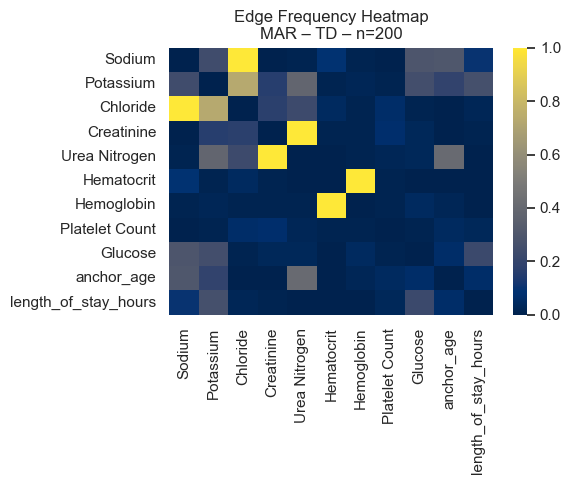

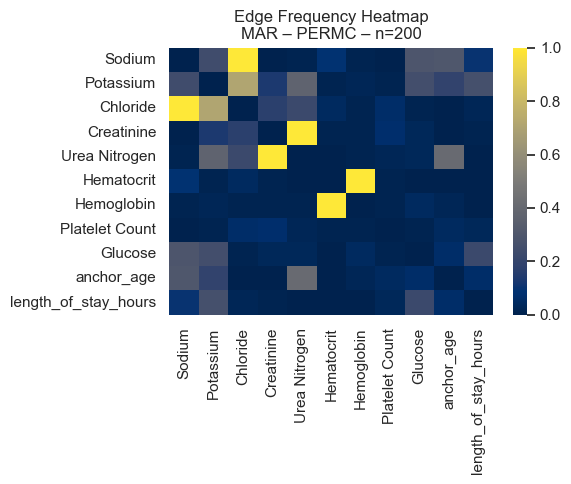

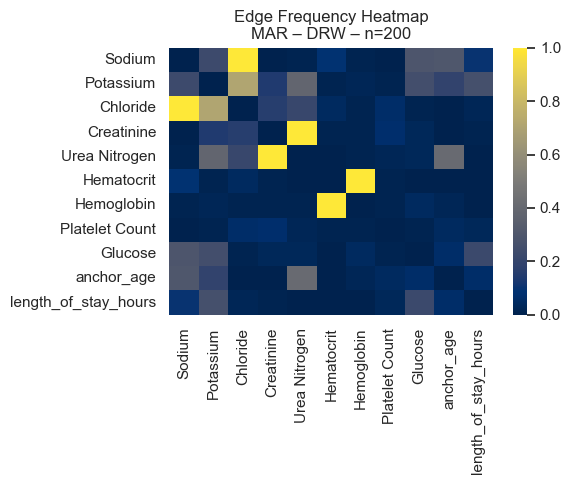

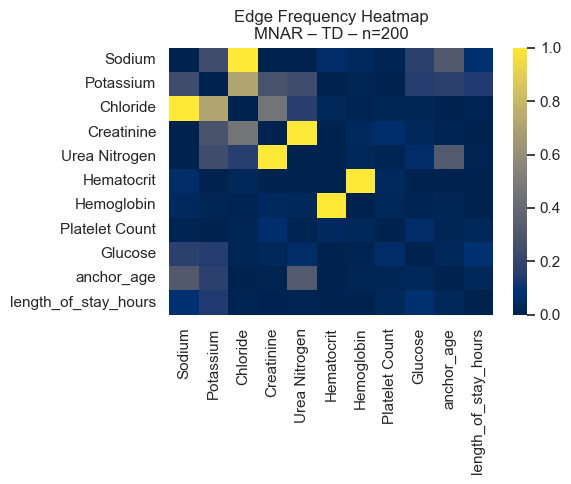

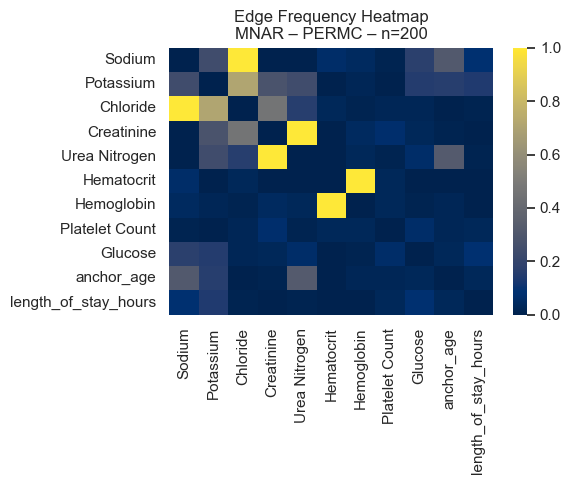

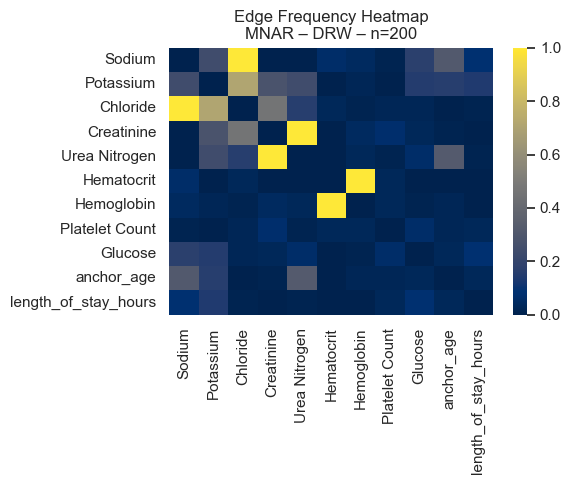

In [31]:
methods = ["td", "permc", "drw"]
modes = ["MAR", "MNAR"]
n = 200   
for mode in modes:
    for method in methods:

        # Compute edge frequency matrix
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            F,
            xticklabels=mvpc_vars,
            yticklabels=mvpc_vars,
            cmap="cividis",
            vmin=0,
            vmax=1,
            cbar=True
        )

        plt.title(f"Edge Frequency Heatmap\n{mode} – {method.upper()} – n={n}")
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


In [32]:
for mode in modes:
    for method in methods:
        F = edge_frequency_matrix(all_skeletons[(mode, method, n)])
        print(f"\n=== {mode} – {method.upper()} – n={n} ===")
        display(pd.DataFrame(F, index=mvpc_vars, columns=mvpc_vars).round(2))



=== MAR – TD – n=200 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.24,1.00,0.00,0.01,0.09,0.01,0.00,0.29,0.30,0.10
Potassium,0.24,0.00,0.73,0.16,0.38,0.01,0.02,0.01,0.25,0.19,0.26
Chloride,1.00,0.73,0.00,0.17,0.23,0.04,0.01,0.06,0.01,0.00,0.02
Creatinine,0.00,0.16,0.17,0.00,1.00,0.01,0.01,0.07,0.03,0.00,0.01
Urea Nitrogen,0.01,0.38,0.23,1.00,0.00,0.00,0.01,0.02,0.03,0.41,0.00
Hematocrit,0.09,0.01,0.04,0.01,0.00,0.00,1.00,0.01,0.00,0.00,0.00
Hemoglobin,0.01,0.02,0.01,0.01,0.01,1.00,0.00,0.01,0.04,0.02,0.00
Platelet Count,0.00,0.01,0.06,0.07,0.02,0.01,0.01,0.00,0.01,0.04,0.03
Glucose,0.29,0.25,0.01,0.03,0.03,0.00,0.04,0.01,0.00,0.06,0.22
anchor_age,0.30,0.19,0.00,0.00,0.41,0.00,0.02,0.04,0.06,0.00,0.06



=== MAR – PERMC – n=200 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.24,1.00,0.00,0.01,0.09,0.01,0.00,0.29,0.30,0.10
Potassium,0.24,0.00,0.71,0.13,0.37,0.01,0.02,0.01,0.25,0.19,0.26
Chloride,1.00,0.71,0.00,0.17,0.22,0.04,0.01,0.06,0.01,0.00,0.02
Creatinine,0.00,0.13,0.17,0.00,1.00,0.01,0.01,0.07,0.03,0.00,0.01
Urea Nitrogen,0.01,0.37,0.22,1.00,0.00,0.00,0.01,0.02,0.03,0.41,0.00
Hematocrit,0.09,0.01,0.04,0.01,0.00,0.00,1.00,0.01,0.00,0.00,0.00
Hemoglobin,0.01,0.02,0.01,0.01,0.01,1.00,0.00,0.01,0.04,0.02,0.00
Platelet Count,0.00,0.01,0.06,0.07,0.02,0.01,0.01,0.00,0.01,0.04,0.03
Glucose,0.29,0.25,0.01,0.03,0.03,0.00,0.04,0.01,0.00,0.06,0.22
anchor_age,0.30,0.19,0.00,0.00,0.41,0.00,0.02,0.04,0.06,0.00,0.06



=== MAR – DRW – n=200 ===


...

,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.24,1.00,0.00,0.00,0.06,0.04,0.01,0.17,0.31,0.08
Potassium,0.24,0.00,0.71,0.28,0.24,0.00,0.02,0.00,0.15,0.17,0.14
Chloride,1.00,0.71,0.00,0.46,0.16,0.03,0.01,0.02,0.02,0.00,0.01
Creatinine,0.00,0.28,0.46,0.00,1.00,0.00,0.04,0.07,0.03,0.01,0.00
Urea Nitrogen,0.00,0.24,0.16,1.00,0.00,0.00,0.03,0.01,0.06,0.32,0.01
Hematocrit,0.06,0.00,0.03,0.00,0.00,0.00,1.00,0.04,0.00,0.00,0.00
Hemoglobin,0.04,0.02,0.01,0.04,0.03,1.00,0.00,0.03,0.01,0.02,0.00
Platelet Count,0.01,0.00,0.02,0.07,0.01,0.04,0.03,0.00,0.06,0.02,0.03
Glucose,0.17,0.15,0.02,0.03,0.06,0.00,0.01,0.06,0.00,0.03,0.08
anchor_age,0.31,0.17,0.00,0.01,0.32,0.00,0.02,0.02,0.03,0.00,0.03



=== MNAR – PERMC – n=200 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.24,1.00,0.00,0.00,0.06,0.04,0.01,0.17,0.31,0.08
Potassium,0.24,0.00,0.71,0.28,0.24,0.00,0.02,0.00,0.15,0.16,0.14
Chloride,1.00,0.71,0.00,0.46,0.16,0.03,0.01,0.02,0.02,0.00,0.01
Creatinine,0.00,0.28,0.46,0.00,1.00,0.00,0.04,0.07,0.03,0.01,0.00
Urea Nitrogen,0.00,0.24,0.16,1.00,0.00,0.00,0.03,0.01,0.06,0.32,0.01
Hematocrit,0.06,0.00,0.03,0.00,0.00,0.00,1.00,0.03,0.00,0.00,0.00
Hemoglobin,0.04,0.02,0.01,0.04,0.03,1.00,0.00,0.03,0.01,0.02,0.00
Platelet Count,0.01,0.00,0.02,0.07,0.01,0.03,0.03,0.00,0.06,0.02,0.03
Glucose,0.17,0.15,0.02,0.03,0.06,0.00,0.01,0.06,0.00,0.03,0.08
anchor_age,0.31,0.16,0.00,0.01,0.32,0.00,0.02,0.02,0.03,0.00,0.03



=== MNAR – DRW – n=200 ===


,Sodium,Potassium,Chloride,Creatinine,Urea Nitrogen,Hematocrit,Hemoglobin,Platelet Count,Glucose,anchor_age,length_of_stay_hours
Sodium,0.00,0.24,1.00,0.00,0.00,0.06,0.04,0.01,0.17,0.31,0.08
Potassium,0.24,0.00,0.71,0.28,0.24,0.00,0.02,0.00,0.15,0.16,0.14
Chloride,1.00,0.71,0.00,0.46,0.16,0.03,0.01,0.02,0.02,0.00,0.01
Creatinine,0.00,0.28,0.46,0.00,1.00,0.00,0.04,0.07,0.03,0.01,0.00
Urea Nitrogen,0.00,0.24,0.16,1.00,0.00,0.00,0.03,0.01,0.06,0.32,0.01
Hematocrit,0.06,0.00,0.03,0.00,0.00,0.00,1.00,0.03,0.00,0.00,0.00
Hemoglobin,0.04,0.02,0.01,0.04,0.03,1.00,0.00,0.03,0.01,0.02,0.00
Platelet Count,0.01,0.00,0.02,0.07,0.01,0.03,0.03,0.00,0.06,0.02,0.03
Glucose,0.17,0.15,0.02,0.03,0.06,0.00,0.01,0.06,0.00,0.03,0.08
anchor_age,0.31,0.16,0.00,0.01,0.32,0.00,0.02,0.02,0.03,0.00,0.03


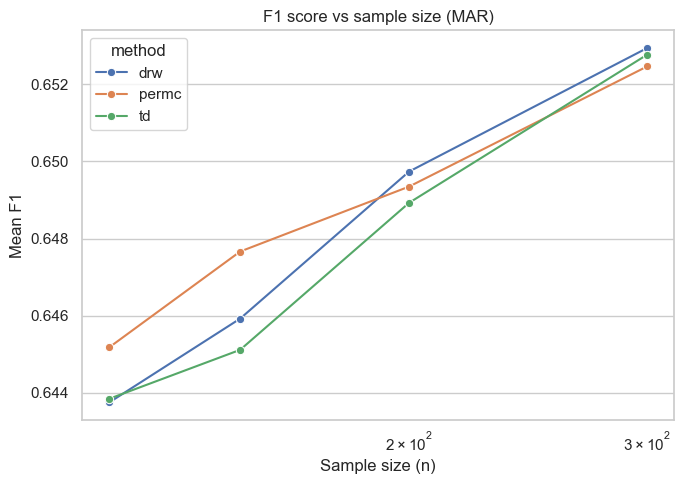

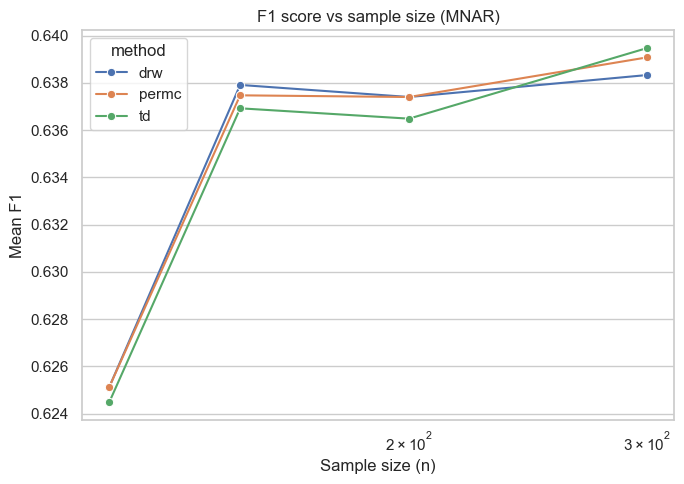

In [ ]:

# F1 vs sample size

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_f1",
    hue="method",
    marker="o",
    errorbar="sd"   
)

plt.xscale("log")
plt.title("F1 score vs sample size (MAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MNAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_f1",
    hue="method",
    marker="o",
    errorbar="sd"
)

plt.xscale("log")
plt.title("F1 score vs sample size (MNAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean F1")
plt.tight_layout()
plt.show()

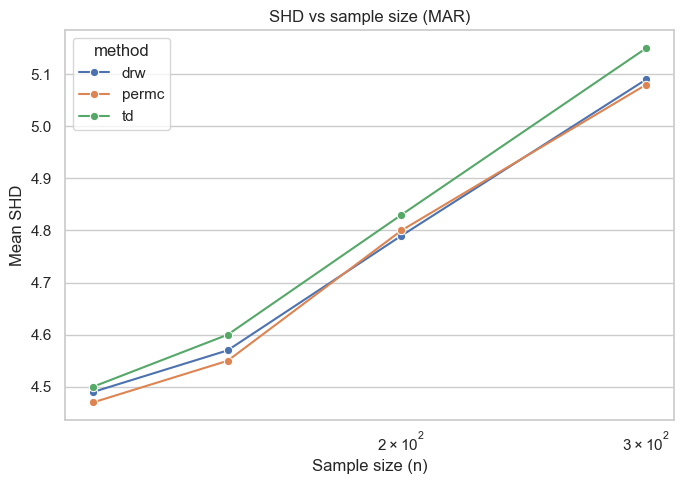

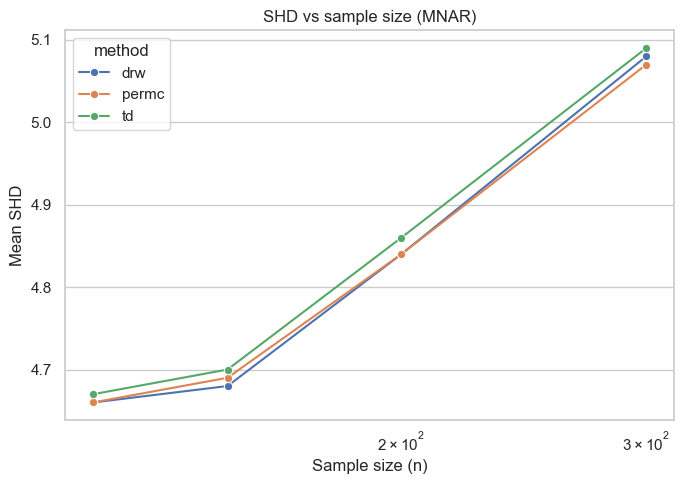

In [ ]:

# SHD vs sample size

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_shd",
    hue="method",
    marker="o"
)

plt.xscale("log")
plt.title("SHD vs sample size (MAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean SHD")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sub = summary_metrics[summary_metrics["mode"] == "MNAR"]

sns.lineplot(
    data=sub,
    x="n",
    y="mean_shd",
    hue="method",
    marker="o"
)

plt.xscale("log")
plt.title("SHD vs sample size (MNAR)")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean SHD")
plt.tight_layout()
plt.show()

In [36]:
print(all_skeletons.keys())

dict_keys([('MAR', 'td', 120), ('MAR', 'permc', 120), ('MAR', 'drw', 120), ('MNAR', 'td', 120), ('MNAR', 'permc', 120), ('MNAR', 'drw', 120), ('MAR', 'td', 150), ('MAR', 'permc', 150), ('MAR', 'drw', 150), ('MNAR', 'td', 150), ('MNAR', 'permc', 150), ('MNAR', 'drw', 150), ('MAR', 'td', 200), ('MAR', 'permc', 200), ('MAR', 'drw', 200), ('MNAR', 'td', 200), ('MNAR', 'permc', 200), ('MNAR', 'drw', 200), ('MAR', 'td', 300), ('MAR', 'permc', 300), ('MAR', 'drw', 300), ('MNAR', 'td', 300), ('MNAR', 'permc', 300), ('MNAR', 'drw', 300)])


In [37]:
print("Reference edges:", skeleton_ref.sum()/2)

for key in all_skeletons:
    mode, method, n = key
    avg_edges = np.mean([S.sum()/2 for S in all_skeletons[key]])
    print(mode, method, n, avg_edges)

Reference edges: 6.0
MAR td 120 6.48
MAR permc 120 6.45
MAR drw 120 6.45
MNAR td 120 6.35
MNAR permc 120 6.34
MNAR drw 120 6.34
MAR td 150 6.86
MAR permc 150 6.81
MAR drw 150 6.81
MNAR td 150 6.86
MNAR permc 150 6.85
MNAR drw 150 6.84
MAR td 200 7.69
MAR permc 200 7.62
MAR drw 200 7.61
MNAR td 200 7.26
MNAR permc 200 7.24
MNAR drw 200 7.24
MAR td 300 8.75
MAR permc 300 8.56
MAR drw 300 8.59
MNAR td 300 8.09
MNAR permc 300 8.01
MNAR drw 300 8.02
